<a href="https://colab.research.google.com/github/wranjan4710/Exploratory-Data-Analysis-on-Amazon-s-Diwali-Campaign-Performance-2025/blob/main/exploratory_data_analysis_on_amazon_s_diwali_campaign_performance_2025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Exploratory Data Analysis on Amazon’s Diwali Campaign Performance 2025**


# 1. Introduction
During the Diwali 2025 campaign, Amazon achieved significant sales growth across various product categories and regions.

The objective of this project is to perform **Exploratory Data Analysis (EDA)** to evaluate campaign performance and generate meaningful business insights.

This project focuses on:



*   Analyzing overall **sales performance**
*   Understanding **profit and loss**

*  Evaluating **product behavior**
*   Performing **state-wise demand analysis**

*   Studying **time-series sales trends**
*  Developing **advanced KPIs** for deeper insights

















In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 2. Dataset Understanding (EDA)

Step 1: Import Libraries

In [ ]:
# Basic Libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# Date Handling
from datetime import datetime

# Display settings
pd.set_option('display.max_columns', None)

print("Libraries Imported Successfully ✅")

Libraries Imported Successfully ✅


Upload Dataset

Step 2: Load Dataset

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/1st project/Exploratory Data Analysis on Amazon’s Diwali Campaign Performance 2025.csv")
df.columns = df.columns.str.strip()
df.head()

,Order_ID,Date,Customer_ID,Product_Category,Product_Name,Quantity,Unit_Price_INR,Total_Sales_INR,Payment_Method,Delivery_Status,Review_Rating,Review_Text,State,Country
0,ORD100000,25-01-2025,CUST2796,Home & Kitchen,Cookware Set,2,25574.41,51148.82,Credit Card,Returned,1,Waste of money,Sikkim,India
1,ORD100001,28-08-2025,CUST9669,Beauty,Hair Dryer,1,19361.41,19361.41,Debit Card,Returned,5,Excellent product!,Telangana,India
2,ORD100002,27-02-2025,CUST5808,Electronics,Tablet,3,38476.22,115428.66,Cash on Delivery,Delivered,3,Fair deal,Nagaland,India
3,ORD100003,24-02-2025,CUST5889,Electronics,Headphones,5,38145.72,190728.60,Credit Card,Delivered,5,Highly recommend!,Assam,India
4,ORD100004,15-06-2025,CUST9005,Clothing,Saree,5,45940.98,229704.90,UPI,Delivered,5,Highly recommend!,Odisha,India


Step 3: Basic EDA

In [ ]:
df.shape


(15000, 14)

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          15000 non-null  object 
 1   Date              15000 non-null  object 
 2   Customer_ID       15000 non-null  object 
 3   Product_Category  15000 non-null  object 
 4   Product_Name      15000 non-null  object 
 5   Quantity          15000 non-null  int64  
 6   Unit_Price_INR    15000 non-null  float64
 7   Total_Sales_INR   15000 non-null  float64
 8   Payment_Method    15000 non-null  object 
 9   Delivery_Status   15000 non-null  object 
 10  Review_Rating     15000 non-null  int64  
 11  Review_Text       15000 non-null  object 
 12  State             15000 non-null  object 
 13  Country           15000 non-null  object 
dtypes: float64(2), int64(2), object(10)
memory usage: 1.6+ MB


In [ ]:
df.describe()


,Quantity,Unit_Price_INR,Total_Sales_INR,Review_Rating
count,15000.000000,15000.000000,15000.000000,15000.000000
mean,2.984667,24955.313715,74544.120233,3.040133
std,1.422826,14401.316925,59369.654155,1.411048
min,1.000000,202.570000,204.050000,1.000000
25%,2.000000,12512.937500,27087.852500,2.000000
50%,3.000000,24878.755000,57293.570000,3.000000
75%,4.000000,37496.170000,112188.600000,4.000000
max,5.000000,49994.430000,249955.500000,5.000000


In [ ]:
df.isnull().sum()

,0
Order_ID,0
Date,0
Customer_ID,0
Product_Category,0
Product_Name,0
Quantity,0
Unit_Price_INR,0
Total_Sales_INR,0
Payment_Method,0
Delivery_Status,0


Data Cleaning

In [ ]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

# Check if any date became null
print("Null Dates:", df["Date"].isnull().sum())

Null Dates: 0


/tmp/ipykernel_5166/2175786605.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["Date"] = pd.to_datetime(df["Date"], errors="coerce")


# 3. Understanding & Developing Unique KPIs

KPI (Key Performance Indicator) is a measurable value used to evaluate the performance of a business or campaign. It helps in tracking progress and making data-driven decisions.

Common KPIs:



*  **Total Revenue –** The overall income generated from sales.

*   **Total Profit –** The net earnings after deducting all costs.

*   **Average Order Value (AOV) –** The average amount spent per order.
*  **Return Rate –** The percentage of products returned by customers.

*   **Customer Rating –** The average feedback score given by customers.















**Basic KPIs-**

In [ ]:
total_revenue = df["Total_Sales_INR"].sum()
total_quantity = df["Quantity"].sum()

print("Total Revenue:", total_revenue)
print("Total Quantity Sold:", total_quantity)

Total Revenue: 1118161803.5
Total Quantity Sold: 44770


**Create Profit Column (Assume 25% Margin)**

In [ ]:
df["Profit"] = df["Total_Sales_INR"] * 0.25
total_profit = df["Profit"].sum()

print("Total Profit:", total_profit)

Total Profit: 279540450.875


# **Find CRV using States-wise %(Contribution Share)**

(a). Group by State

In [ ]:
state_sales = df.groupby("State")["Total_Sales_INR"].sum().reset_index()

(b). Calculate Total Sales

In [ ]:
total_sales = state_sales["Total_Sales_INR"].sum()

(c). Calculate CRV (Contribution %)

In [ ]:
total_sales = state_sales["Total_Sales_INR"].sum()

(d). Show Result

In [ ]:
state_sales.head(30)

,State,Total_Sales_INR
0,Andhra Pradesh,36237577.25
1,Arunachal Pradesh,39348777.94
2,Assam,38739460.17
3,Bihar,41669240.44
4,Chhattisgarh,42857545.27
5,Goa,40488243.03
6,Gujarat,36226185.91
7,Haryana,39171925.41
8,Himachal Pradesh,38182171.87
9,Jharkhand,39606674.07


(e). Add Grand Total

In [ ]:
state_sales["CRV (%)"] = (state_sales["Total_Sales_INR"] / total_sales) * 100
print("Total Sales:", total_sales)
print("Total CRV:", state_sales["CRV (%)"].sum())

Total Sales: 1118161803.5
Total CRV: 99.99999999999999


# 4. Profit Efficiency Index (PEI)
 Formula:

**PEI= Profit/Total Sales**



In [ ]:
df["PEI"] = df["Profit"] / df["Total_Sales_INR"]
df[["Total_Sales_INR","Profit","PEI"]].head()

,Total_Sales_INR,Profit,PEI
0,51148.82,12787.2050,0.25
1,19361.41,4840.3525,0.25
2,115428.66,28857.1650,0.25
3,190728.60,47682.1500,0.25
4,229704.90,57426.2250,0.25


**Product Performance Ratio (PPR)**

In [ ]:
total_sales = df["Total_Sales_INR"].sum()
df["PPR"] = df["Total_Sales_INR"] / total_sales
df[["Product_Name","PPR"]].head()

,Product_Name,PPR
0,Cookware Set,0.000046
1,Hair Dryer,0.000017
2,Tablet,0.000103
3,Headphones,0.000171
4,Saree,0.000205


**Product Satisfaction Index (PSI)**

**`Formula:`**
**PSI = Rating × Quantity / 10**

In [ ]:
df["PSI"] = (df["Review_Rating"] * df["Quantity"]) / 10
df[["Product_Name","Review_Rating","PSI"]].head()

,Product_Name,Review_Rating,PSI
0,Cookware Set,1,0.2
1,Hair Dryer,5,0.5
2,Tablet,3,0.9
3,Headphones,5,2.5
4,Saree,5,2.5


**Demand Intensity Value (DIV)**

In [ ]:
df["DIV"] = df["Quantity"] / 30
df[["Product_Name","DIV"]].head()

,Product_Name,DIV
0,Cookware Set,0.066667
1,Hair Dryer,0.033333
2,Tablet,0.100000
3,Headphones,0.166667
4,Saree,0.166667


**Customer Purchase Variability (CPV)**

In [ ]:
df["CPV"] = df.groupby("Customer_ID")["Quantity"].transform("std")
df[["Customer_ID","Quantity","CPV"]].head()

,Customer_ID,Quantity,CPV
0,CUST2796,2,0.577350
1,CUST9669,1,1.732051
2,CUST5808,3,1.414214
3,CUST5889,5,1.760682
4,CUST9005,5,2.121320


**Unit Price Stability Index (UPSI)**

In [ ]:
price_std = df["Unit_Price_INR"].std()
price_mean = df["Unit_Price_INR"].mean()

UPSI = 1 - (price_std / price_mean)
print("UPSI:", UPSI)

UPSI: 0.4229158130513644


**State-wise Market Penetration Index (SMPI)**

In [ ]:
state_sales = df.groupby("State")["Total_Sales_INR"].sum()
SMPI = state_sales / total_sales

SMPI.sort_values(ascending=False).head(30)

,Total_Sales_INR
State,
Sikkim,0.038557
Rajasthan,0.038372
Chhattisgarh,0.038329
Meghalaya,0.038253
Tamil Nadu,0.037533
Uttar Pradesh,0.037285
Bihar,0.037266
West Bengal,0.036843
Tripura,0.036760


**Time-Series Analysis**

In [ ]:
df.set_index("Date", inplace=True)

**📈 Monthly Revenue Trend**

/tmp/ipykernel_5166/2861476085.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = df.resample("M")["Total_Sales_INR"].sum()


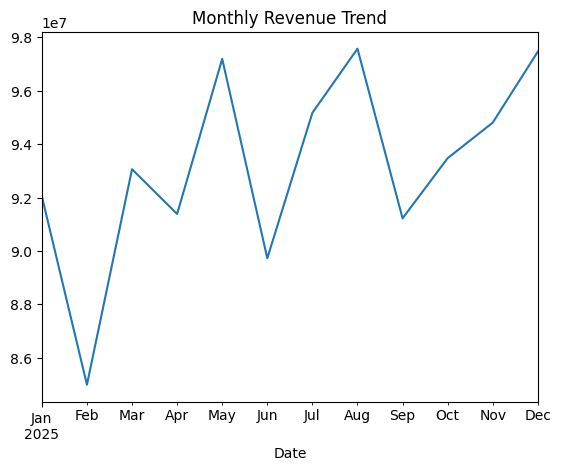

In [ ]:
monthly_sales = df.resample("M")["Total_Sales_INR"].sum()

plt.figure()
monthly_sales.plot()
plt.title("Monthly Revenue Trend")
plt.show()

**📊 MMPI**

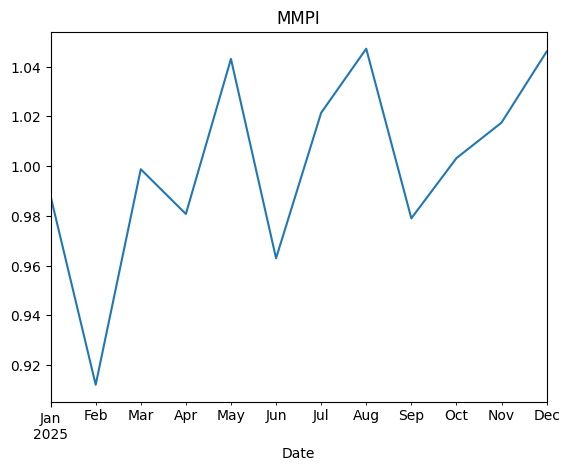

In [ ]:
MMPI = monthly_sales / monthly_sales.mean()

plt.figure()
MMPI.plot(title="MMPI")
plt.show()

**📊 MQPI**

/tmp/ipykernel_5166/3885104881.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_qty = df.resample("M")["Quantity"].sum()


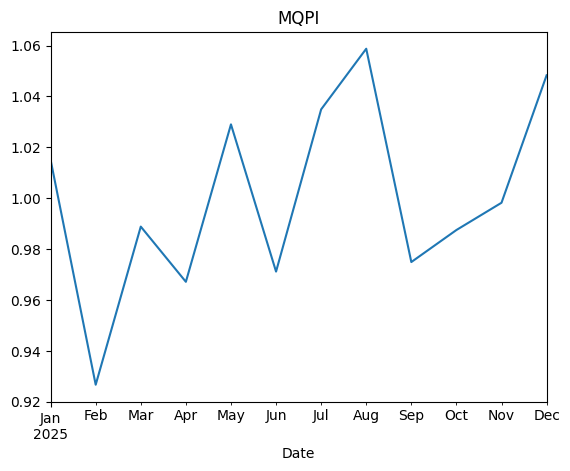

In [ ]:
monthly_qty = df.resample("M")["Quantity"].sum()
MQPI = monthly_qty / monthly_qty.mean()

plt.figure()
MQPI.plot(title="MQPI")
plt.show()

# Top 10 Products by Revenue

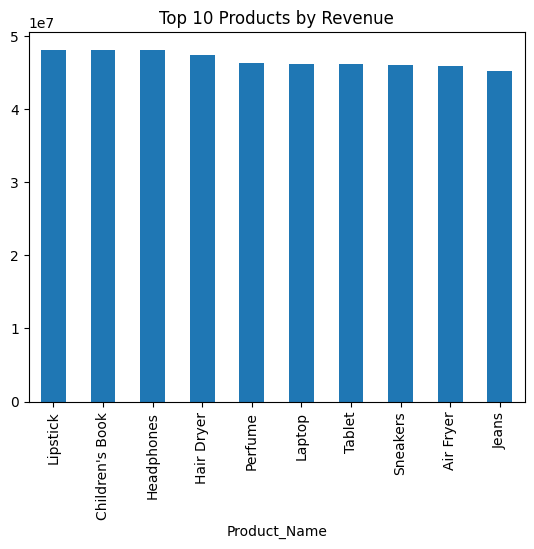

In [ ]:
top_products = df.groupby("Product_Name")["Total_Sales_INR"].sum().sort_values(ascending=False).head(10)

plt.figure()
top_products.plot(kind="bar")
plt.title("Top 10 Products by Revenue")
plt.show()

# Scatter Plot (Revenue vs Profit)

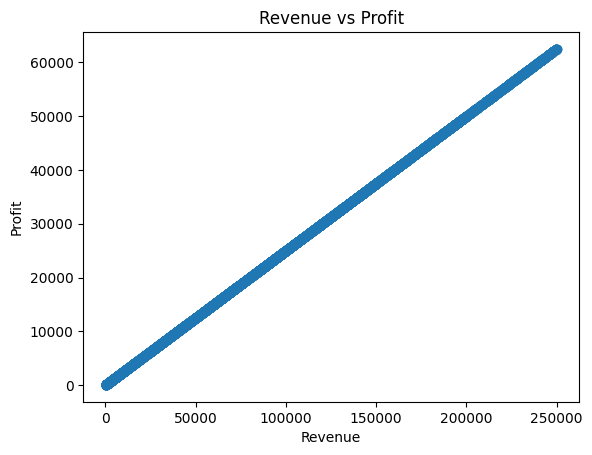

In [ ]:
plt.figure()
plt.scatter(df["Total_Sales_INR"], df["Profit"])
plt.xlabel("Revenue")
plt.ylabel("Profit")
plt.title("Revenue vs Profit")
plt.show()

# Export Final File for Flourish

In [ ]:
df.reset_index(inplace=True)
df.to_csv("Amazon_Diwali_Final_Processed.csv", index=False)

print("File Saved Successfully ✅")

File Saved Successfully ✅


In [ ]:
from google.colab import files

df.reset_index(inplace=True)
df.to_csv("Amazon_Diwali_Final_Processed.csv", index=False)

files.download("Amazon_Diwali_Final_Processed.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>